# Features introduced by closure, queried on their own

For each old query `u`, compute `c=FG(u)`, then set
`h=np.where(u != 0, 0, c)`. This removes whole coordinates,
not just the original activation amount. The original extent
is contained in `G(h)` by construction, and `G(u join h)=G(u)`.

We evaluate 404 cached queries in image/token contexts and full/
declared coordinate spaces: 1,616 cases. Empty-original cases
use the fixed top vector and carry no observed shared evidence.
Sources: `src/lattmc/vision/closure_added*_codexgen.py`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import sparse
from IPython.display import Image, display

root = Path.cwd()
folder = root / "vision_tokens/overcomplete/results"
old_folder = folder / "semantic_reading"
folder = folder / "closure_added"
models = ["topk_k32_s0", "prisma_transcoder",
          "pretrained_ra"]
rows = []
for model in models:
    report = json.loads(
        (folder / f"{model}_codexgen.json").read_text())
    rows.extend({"model": model, **r}
                for r in report["results"])
frame = pd.DataFrame(rows)
assert len(frame) == 1616
frame.groupby(["model", "space", "context"])[
    ["original", "added", "support_h"]].agg(
        ["count", "median", "max"])

original                added  \
                                              count median     max count   
model             space            context                                 
pretrained_ra     native           image        130    0.0     547   130   
                                   patch        130    0.0  140032   130   
                  query_projection image        130    0.0     547   130   
                                   patch        130    0.0  140032   130   
prisma_transcoder native           image        132  171.5     547   132   
                                   patch        132    2.0   26803   132   
                  query_projection image        132  171.5     547   132   
                                   patch        132    2.0   26803   132   
topk_k32_s0       native           image        142   39.0     547   142   
                                   patch        142    2.5  140032   142   
                  query_projection image        142   39.0     547   142   
                                   patch        142    2.5  140032   142   

                                                             support_h  \
                                              median     max     count   
model             space            context                               
pretrained_ra     native           image         0.0     547       130   
                                   patch         0.0  140032       130   
                  query_projection image       547.0     547       130   
                                   patch    140032.0  140032       130   
prisma_transcoder native           image       198.0     547       132   
                                   patch         2.0   26803       132   
                  query_projection image       547.0     547       132   
                                   patch     26803.0   26803       132   
topk_k32_s0       native           image       188.5     547       142   
                                   patch         2.5  140032       142   
                  query_projection image       547.0     547       142   
                                   patch    140032.0  140032       142   

                                                            
                                             median    max  
model             space            context                  
pretrained_ra     native           image    21847.5  21877  
                                   patch    21871.0  21877  
                  query_projection image        0.0     19  
                                   patch        0.0     19  
prisma_transcoder native           image      620.5   4438  
                                   patch       45.0   4443  
                  query_projection image        0.0    355  
                                   patch        0.0    420  
topk_k32_s0       native           image       18.5   1533  
                                   patch       15.0   1534  
                  query_projection image        0.0     21  
                                   patch        0.0     21

## Complete saved-mask and support checks

The separate source audit also recomputes all residual
extents from original sparse codes and tests 6,561 finite
matrix/query cases. Here we independently check saved masks
and the exact support-removal rule for every case.

In [2]:
checked = 0
for model in models:
    old = {}
    for suffix in ["", "_followup"]:
        path = old_folder / f"{model}{suffix}_codexgen.json"
        old.update({r["name"]: r
                    for r in json.loads(path.read_text())
                    ["results"]})
    closed = sparse.load_npz(
        folder / f"{model}_closed_codexgen.npz")
    with np.load(folder / f"{model}_masks_codexgen.npz") as m:
        for r in [r for r in rows if r["model"] == model]:
            i = r["index"]
            a, b = m[f"{i}_original"], m[f"{i}_added"]
            assert a.sum() == r["original"]
            assert b.sum() == r["added"]
            assert np.all(a <= b)
            q = old[r["name"]]
            h = closed[r["vector_row"]].toarray()[0]
            support = np.array(q["features"])[
                np.array(q["query"]) != 0]
            h[support] = 0
            assert np.count_nonzero(h) == r["support_h"]
            assert np.all(h[support] == 0)
            checked += 1
assert checked == 1616
print(f"Verified {checked} saved cases.")

Verified 1616 saved cases.


## Inspect new returned images

The final figure shows illustrative new members. Red cells
are common witnesses; blue cells mark maxima for up to four
limiting coordinates in a distributed query. They are not
receptive fields or causal attributions. Initial anonymous
readings and full/rank-sampled galleries are saved separately.

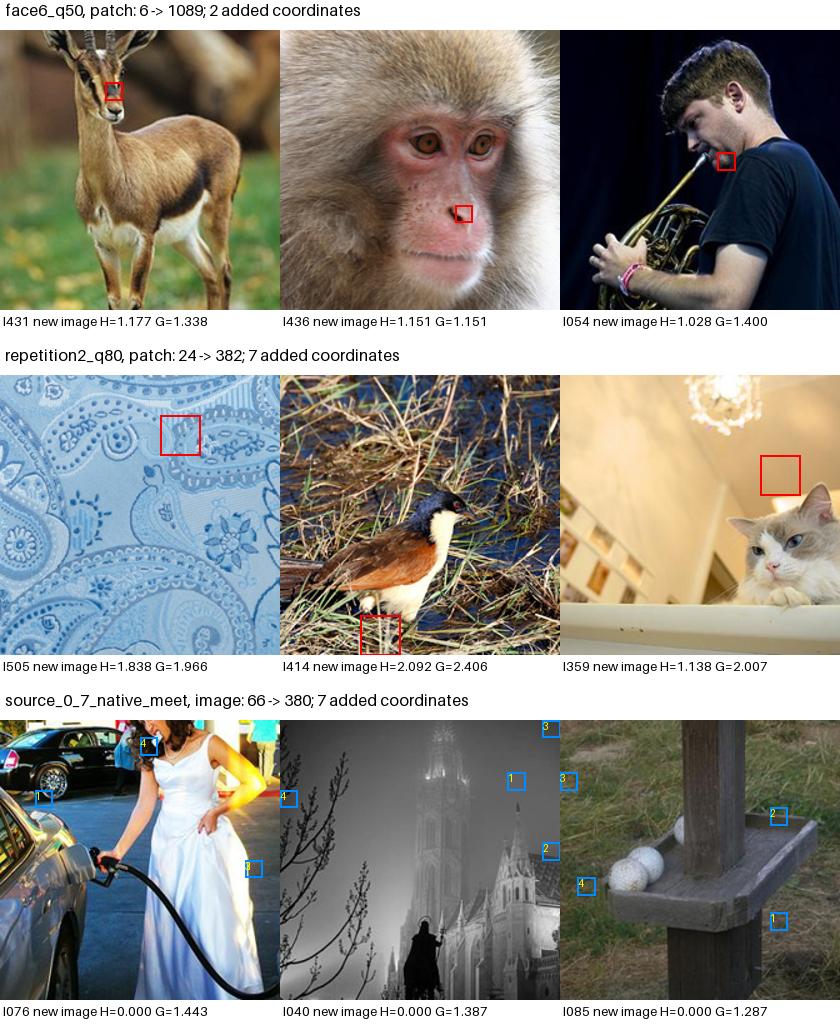

In [3]:
display(Image(filename=str(folder / "figures" /
    "closure_added_examples_codexgen.png")))

## Cross-collection follow-up

After the initial reading, inspect all 21 facial-pair
matches outside Imagewoof and Pets. This deliberately checks
the apparent generality beyond the dominant pet collections.
It is an exploratory follow-up, not blind validation.

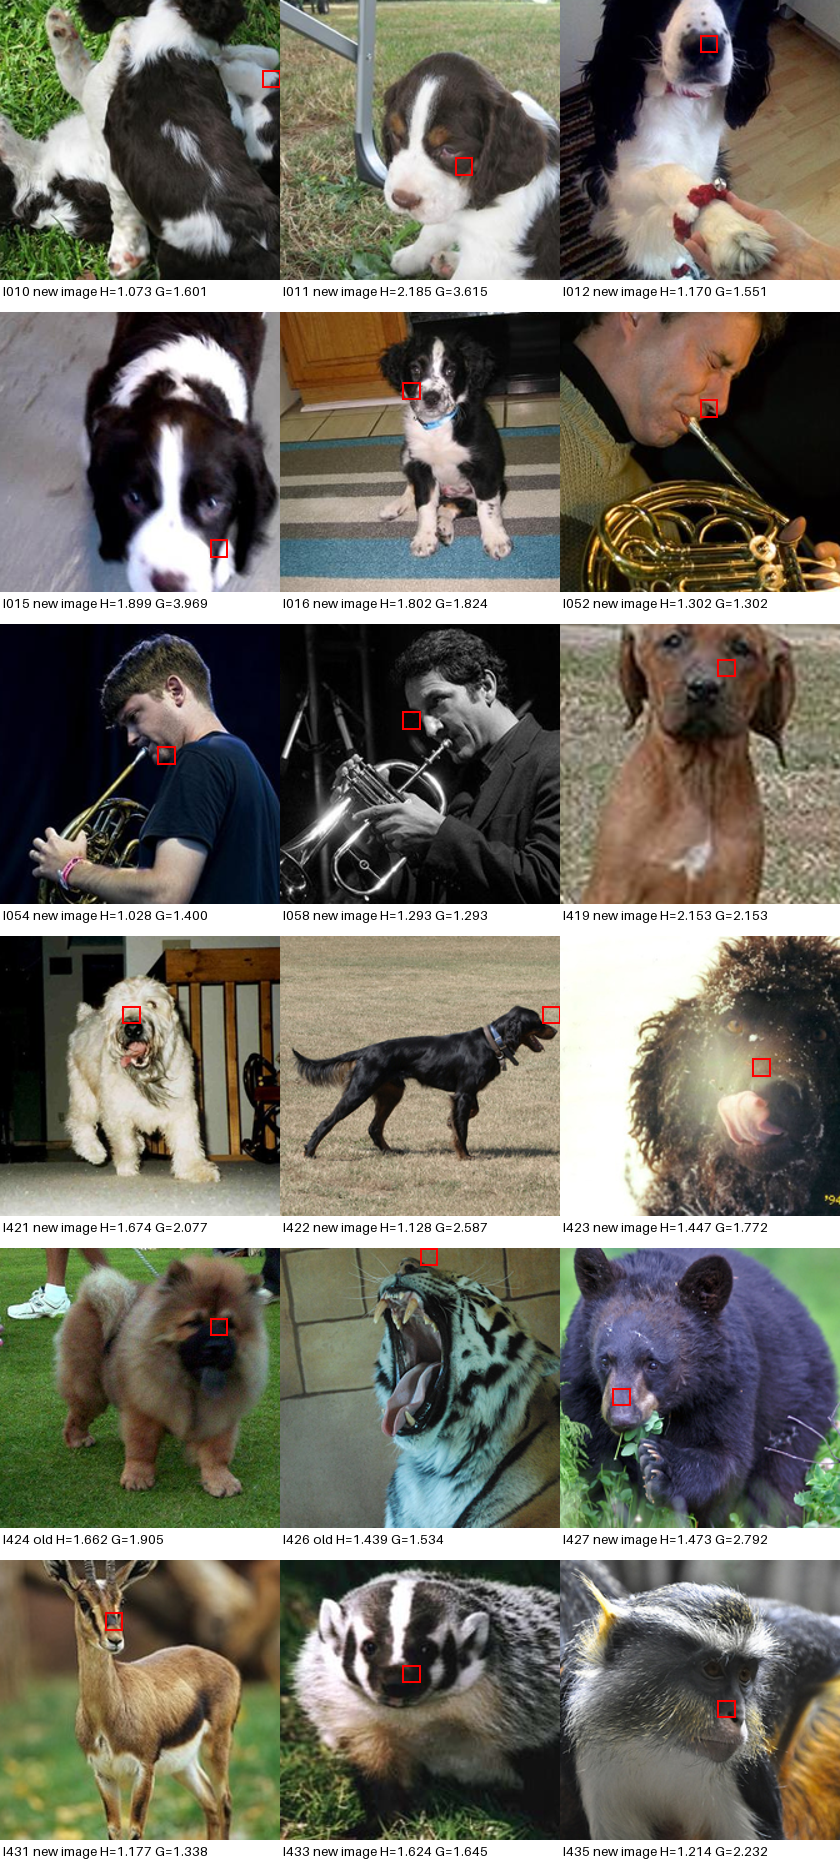

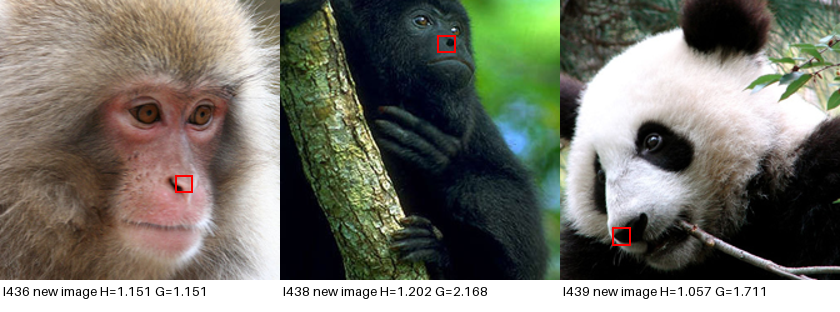

In [4]:
for page in range(2):
    display(Image(filename=str(folder / "figures" /
        f"face_transfer_{page}.png")))

## Exact added vectors and control outcomes

Controls compare individual added features and 0.9/1/1.1
threshold multipliers. These perturbations need not preserve
the original extent; the theorem applies to the exact h.

In [5]:
controls = json.loads(
    (folder / "controls_codexgen.json").read_text())
for name in ["face6_q50:patch", "face3_q80:patch",
             "performance3_q80:image"]:
    item = controls["topk_k32_s0"][name]
    print(name, "added coordinates:", len(item["features"]))
    display(pd.DataFrame(item["scales"]))
    if len(item["features"]) <= 10:
        display(pd.DataFrame({"feature": item["features"],
                              "threshold": item["values"]}))

face6_q50:patch added coordinates: 2


,scale,patches,common,pooled
0,0.9,1272,235,329
1,1.0,1089,221,319
2,1.1,840,189,307


,feature,threshold
0,399,2.269982
1,515,1.625866


face3_q80:patch added coordinates: 10


,scale,patches,common,pooled
0,0.9,113,59,133
1,1.0,61,35,94
2,1.1,19,15,68


,feature,threshold
0,14,1.947493
1,468,1.913218
2,490,4.229202
3,714,2.178233
4,805,1.713348
5,1054,1.847419
6,1272,2.681039
7,1318,2.875442
8,1430,2.671390
9,1481,5.395412


performance3_q80:image added coordinates: 261


,scale,patches,common,pooled
0,0.9,0,0,3
1,1.0,0,0,3
2,1.1,0,0,0


## Later labels and interpretation limits

Label tabulations describe the same objects, not independent
relevance judgments. Prior project familiarity is explicit.
Broad facial relationships, weak texture/context requirements,
and high-dimensional instance recovery are different outcomes.
A zero residual is universal; an empty-original closure is
vacuous. None establishes downstream causal use.

In [6]:
display(controls["topk_k32_s0"]["face3_q80:patch"]["labels"])
nonempty = frame[~frame.empty_original]
nonempty.groupby(["model", "space", "context"])[
    ["zero_h", "same_extent", "universal_h"]].sum()

{'Shih-Tzu': 1,
 'Rhodesian ridgeback': 2,
 'Beagle': 2,
 'English foxhound': 1,
 'Australian terrier': 1,
 'Old English sheepdog': 2,
 'Samoyed': 2,
 'staffordshire_bull_terrier': 2,
 'yorkshire_terrier': 1,
 'american_bulldog': 2,
 'basset_hound': 3,
 'keeshond': 2,
 'american_pit_bull_terrier': 1,
 'leonberger': 3,
 'saint_bernard': 3,
 'english_setter': 1,
 'newfoundland': 2,
 'english_cocker_spaniel': 1,
 'n02090379': 1,
 'n02096177': 1,
 'n02102973': 1}

zero_h  same_extent  universal_h
model             space            context                                  
pretrained_ra     native           image         0           56           12
                                   patch        41           11           41
                  query_projection image        58           12           63
                                   patch        55           11           55
prisma_transcoder native           image         0           32            5
                                   patch         8           11            8
                  query_projection image       112            7          112
                                   patch        69            6           69
topk_k32_s0       native           image         0           37           12
                                   patch        61           14           61
                  query_projection image       103           11          108
                                   patch        73           11           73